# Unsupervised Visualization Example

**Note:** Prior to running this example notebook, run the command under the 'Unsupervised Visualization' section of the `README`. Save the folders generated from PCA and MHSA visualization in the `example_imgs` folder and adjust paths in this notebook accordingly. 

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import torch
from torch.nn.functional import interpolate

## Create PCA volumes

This function uses the first PCA component to mask the background, and uses the next three components mapped to RGB colorspace to create colormaps of PCA component variation over an image. 

In [2]:
def vis_pca(pth, resize=1.0):
    # load original image, and first 4 PCA components
    img = torch.tensor(nib.load(f'{pth}/orig.nii.gz').get_fdata())
    pca0 = torch.tensor(nib.load(f'{pth}/nifti_0.nii.gz').get_fdata())
    pca1 = torch.tensor(nib.load(f'{pth}/nifti_1.nii.gz').get_fdata())
    pca2 = torch.tensor(nib.load(f'{pth}/nifti_2.nii.gz').get_fdata())
    pca3 = torch.tensor(nib.load(f'{pth}/nifti_3.nii.gz').get_fdata())
    h, w, d = img.shape
    
    # background can usually be masked out with a simple threshold (may arbitrarily need to be > threshold or < threshold)
    # adjust this for your image!
    bg_mask = (pca0 > 0.5).float()
    
    # create PCA volume and normalize each component
    pca_vol = torch.stack([pca1, pca2, pca3], dim=3)
    pca_min = pca_vol.view(-1, 3).min(dim=0).values.reshape(1, 1, 1, -1)
    pca_max = pca_vol.view(-1, 3).max(dim=0).values.reshape(1, 1, 1, -1)
    pca_vol = (pca_vol - pca_min) / (pca_max - pca_min)
    
    # can make volumes smaller for faster visualization
    bg_mask = interpolate(
        bg_mask.unsqueeze(0).unsqueeze(0), size=(int(h*resize), int(w*resize), int(d*resize)), mode='nearest'
    ).bool()[0, 0]
    pca_vol = interpolate(
        pca_vol.unsqueeze(0).permute(0, 4, 1, 2, 3), size=(int(h*resize), int(w*resize), int(d*resize)), mode='nearest'
    )[0].permute(1, 2, 3, 0)
    img = interpolate(
        img.unsqueeze(0).unsqueeze(0), size=(int(h*resize), int(w*resize), int(d*resize)), mode='trilinear'
    )[0, 0]
    
    # set the PCA volume background to white
    pca_vol[bg_mask, :] = 1.0
    
    # this can improve PCA visualization contrast, adjust for your image!
    pca_vol[pca_vol < 0.4] = 0
    return img.numpy(), pca_vol.numpy()


## Visualize example image

This code visualizes an example image using generated PCA and MHSA volumes. 

In [3]:
def plot_attention_maps(z, mhsa_ind, pca_vol, mhsa_vol, lbl=None):

    # create volumes, adjust these paths to your created folders!
    img, pca_vol = vis_pca(pca_vol, resize=1.0)
    mhsa_vol = nib.load(f'{mhsa_vol}/nifti_{mhsa_ind}.nii.gz').get_fdata()

    if lbl is not None:

        import matplotlib.patches as mpatches
        from matplotlib.colors import ListedColormap, BoundaryNorm                                                                                                  
        
        _lc = np.array([                                                                                                                                            
            [0,    0,   0,   0.00],   # bg  — transparent                                                                                                         
            [0,  114, 178,   0.85],   # C1  — #0072B2
            [213,  94,   0,  0.85],   # C2  — #D55E00
            [0,  158, 115,   0.85],   # C3  — #009E73
        ], dtype=float)
        _lc[:, :3] /= 255.0
        label_cmap = ListedColormap(_lc)
        label_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4)
        img_disp = (img - np.percentile(img, 1)) / (np.percentile(img, 99) - np.percentile(img, 1) + 1e-8)
        img_disp = np.clip(img_disp, 0, 1)           

            
        fig, axs = plt.subplots(1, 4, figsize=(15, 5))

        for ax in fig.axes:
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)

                
        # display volumes
        axs[0].imshow(np.rot90(img[:, :, z]), cmap='gray')
        # axs[1].imshow(np.rot90(lbl[:, :, z]), cmap='gray')
        axs[1].imshow(np.rot90(img_disp[:, :, z]), cmap='gray', vmin=0, vmax=1)
        axs[1].imshow(np.rot90(lbl[:, :, z]), cmap=label_cmap, norm=label_norm, alpha=0.75)
        axs[2].imshow(np.rot90(pca_vol[:, :, z, :]))
        axs[3].imshow(np.rot90(img[:, :, z]), cmap='gray')
        axs[3].imshow(np.rot90(mhsa_vol[:, :, z]), cmap='jet', alpha=0.5)


    else:
          
        fig, axs = plt.subplots(1, 3, figsize=(10, 5))

        # display volumes
        axs[0].imshow(np.rot90(img[:, :, z]), cmap='gray')
        axs[1].imshow(np.rot90(pca_vol[:, :, z, :]))
        axs[2].imshow(np.rot90(img[:, :, z]), cmap='gray')
        axs[2].imshow(np.rot90(mhsa_vol[:, :, z]), cmap='jet', alpha=0.5)


    plt.tight_layout()
    plt.show()


In [4]:
# visualize
# process lbl if provided; if not skip to the next step
lbl = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/lbls/TS_0001.nii.gz').get_fdata()
img = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0001/pca_448/orig.nii.gz').get_fdata()

if img.shape != lbl.shape:
    from monai.transforms import Resize
    resize = Resize(spatial_size=img.shape, mode='nearest')
    lbl = resize(lbl[None])[0].numpy()

fg_counts = (lbl > 0).sum(axis=(0, 1))
z = np.argmax(fg_counts) 

/home/ahmadreza/anaconda3/envs/cryoet/lib/python3.9/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


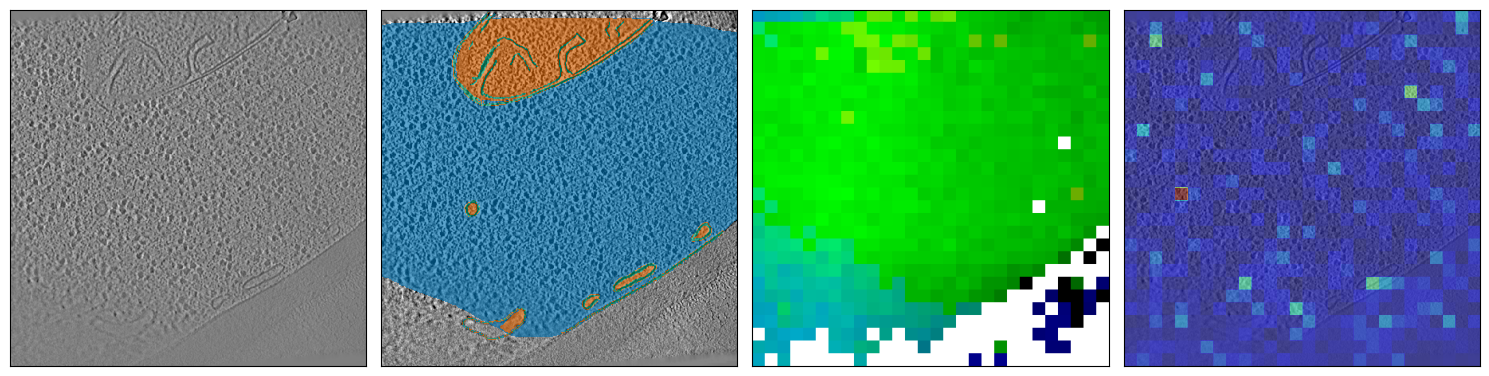

In [5]:
plot_attention_maps(z=z,
                    mhsa_ind=13,
                    pca_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0001/pca_448',
                    mhsa_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0001/mhsa_448',
                    lbl=lbl)

In [6]:
# visualize
# process lbl if provided; if not skip to the next step
lbl = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/lbls/TS_0009.nii.gz').get_fdata()
img = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0009/pca_448/orig.nii.gz').get_fdata()

if img.shape != lbl.shape:
    from monai.transforms import Resize
    resize = Resize(spatial_size=img.shape, mode='nearest')
    lbl = resize(lbl[None])[0].numpy()

fg_counts = (lbl > 0).sum(axis=(0, 1))
z = np.argmax(fg_counts) 

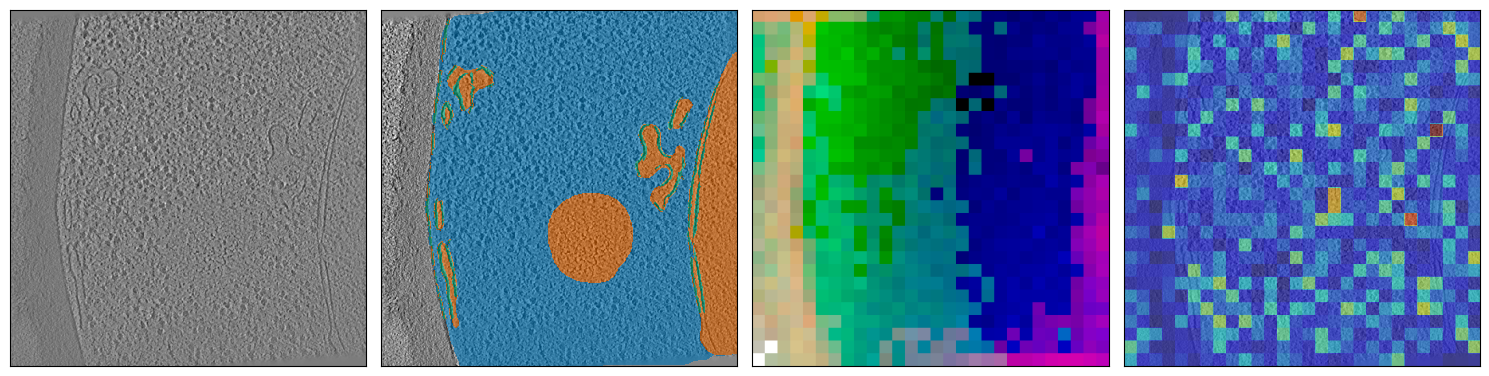

In [7]:
# visualize
plot_attention_maps(z=z,
                    mhsa_ind=0,
                    pca_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0009/pca_448',
                    mhsa_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_0009/mhsa_448',
                    lbl=lbl)

In [8]:
# visualize
# process lbl if provided; if not skip to the next step
lbl = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/lbls/TS_027.nii.gz').get_fdata()
img = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/pca_448/orig.nii.gz').get_fdata()

if img.shape != lbl.shape:
    from monai.transforms import Resize
    resize = Resize(spatial_size=img.shape, mode='nearest')
    lbl = resize(lbl[None])[0].numpy()

fg_counts = (lbl > 0).sum(axis=(0, 1))
z = np.argmax(fg_counts) 

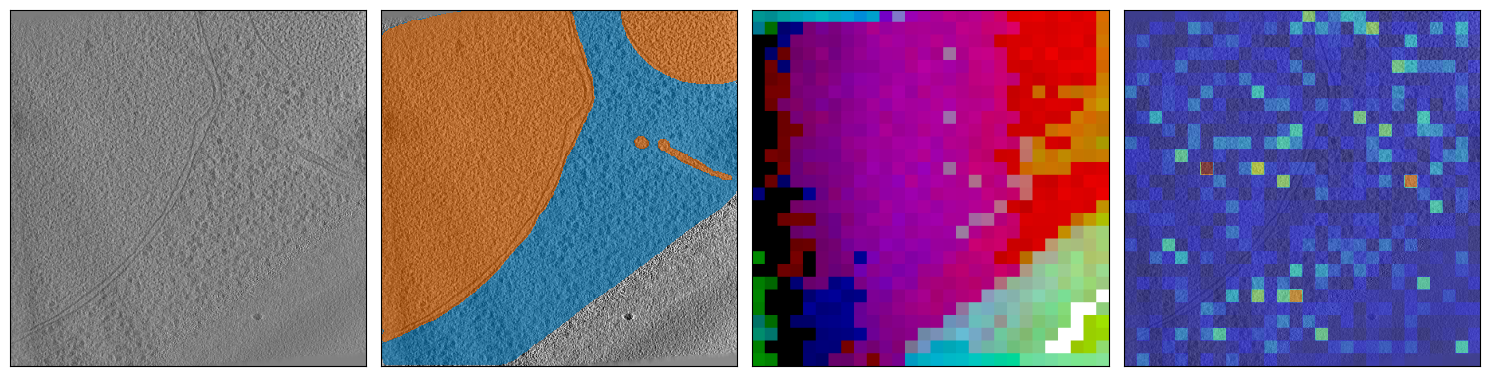

In [13]:
# visualize
plot_attention_maps(z=z,
                    mhsa_ind=2,
                    pca_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/pca_448',
                    mhsa_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/mhsa_448',
                    lbl=lbl)

In [14]:
# visualize
# process lbl if provided; if not skip to the next step
lbl = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/lbls/TS_027.nii.gz').get_fdata()
img = nib.load(f'/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/pca/orig.nii.gz').get_fdata()

if img.shape != lbl.shape:
    from monai.transforms import Resize
    resize = Resize(spatial_size=img.shape, mode='nearest')
    lbl = resize(lbl[None])[0].numpy()

fg_counts = (lbl > 0).sum(axis=(0, 1))
z = np.argmax(fg_counts) 

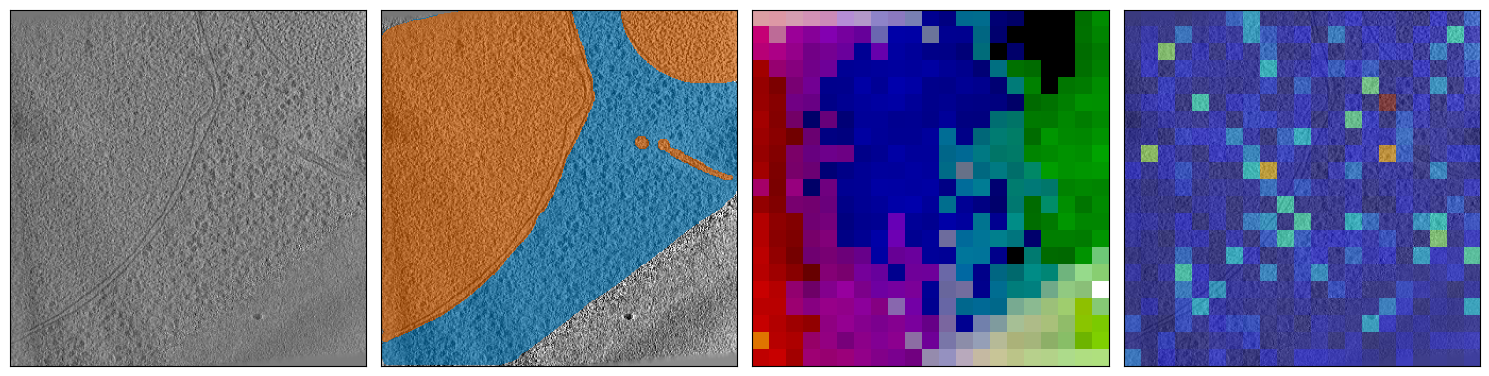

In [16]:
# visualize
plot_attention_maps(z=z,
                    mhsa_ind=2,
                    pca_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/pca',
                    mhsa_vol='/home/ahmadreza/projects/cryo-et/CryoET/visualization/attention_maps/vis_output/TS_027/mhsa',
                    lbl=lbl)